In [1]:
import numpy as np
import pandas as pd
import re
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import collections
import itertools
import seaborn as sns
import tweepy
import datetime
import nltk
from nltk.corpus import stopwords
from PIL import Image
import datetime
from afinn import Afinn
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import RegexpTokenizer
from nltk.stem import WordNetLemmatizer 
from sklearn.feature_extraction.text import TfidfVectorizer
import operator
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from networkx.drawing.nx_agraph import graphviz_layout
import nltk

In [2]:
df = pd.read_excel('C:/Users/jwan0/Youtubecrawl_KR_1022.xlsx')

df.head()

,ID,user_name,content of comments,Translation
0,1,YM Park,태어나서 이렇게 한국적이면서 힙한 컨텐츠를 본적이 없다 진심 천재적이다 이게 공사에...,i've never seen such korean and hip content in...
1,2,유철희,"이건 일년이 지나도, 추후 몇 년이 지나도역대급이라 관련 담당자분들 더 열일 할 수...","even after a year or a few years pass, this is..."
2,3,Deep wish Kim,한국 관광공사에도 일부 꼰대들이 있을텐데 그걸 제끼고 올라온 누군가의 열정과 추진력...,there must be some kkondaes in the korea touri...
3,4,AQ unit7,한두달에 한번은 다시 들으러 오게 되는데 이번엔 콜플 콜라보보고 생각나서 ㅋㅋ서울편...,i come here to listen to it again once or twic...
4,5,Nicolas Goldring,"I've recently gained a passion for Korea, and ...","i've recently gained a passion for korea, and ..."


In [3]:
df = df.astype('string')
df.dtypes

ID                     string[python]
user_name              string[python]
content of comments    string[python]
Translation            string[python]
dtype: object

In [4]:
df['Translation'] = df['Translation'].astype(str).str.lower()
df.head()

,ID,user_name,content of comments,Translation
0,1,YM Park,태어나서 이렇게 한국적이면서 힙한 컨텐츠를 본적이 없다 진심 천재적이다 이게 공사에...,i've never seen such korean and hip content in...
1,2,유철희,"이건 일년이 지나도, 추후 몇 년이 지나도역대급이라 관련 담당자분들 더 열일 할 수...","even after a year or a few years pass, this is..."
2,3,Deep wish Kim,한국 관광공사에도 일부 꼰대들이 있을텐데 그걸 제끼고 올라온 누군가의 열정과 추진력...,there must be some kkondaes in the korea touri...
3,4,AQ unit7,한두달에 한번은 다시 들으러 오게 되는데 이번엔 콜플 콜라보보고 생각나서 ㅋㅋ서울편...,i come here to listen to it again once or twic...
4,5,Nicolas Goldring,"I've recently gained a passion for Korea, and ...","i've recently gained a passion for korea, and ..."


In [5]:
from nltk.tokenize import RegexpTokenizer

regexp = RegexpTokenizer('\w+')

df['text_token']=df['Translation'].apply(regexp.tokenize)
df.head()

,ID,user_name,content of comments,Translation,text_token
0,1,YM Park,태어나서 이렇게 한국적이면서 힙한 컨텐츠를 본적이 없다 진심 천재적이다 이게 공사에...,i've never seen such korean and hip content in...,"[i, ve, never, seen, such, korean, and, hip, c..."
1,2,유철희,"이건 일년이 지나도, 추후 몇 년이 지나도역대급이라 관련 담당자분들 더 열일 할 수...","even after a year or a few years pass, this is...","[even, after, a, year, or, a, few, years, pass..."
2,3,Deep wish Kim,한국 관광공사에도 일부 꼰대들이 있을텐데 그걸 제끼고 올라온 누군가의 열정과 추진력...,there must be some kkondaes in the korea touri...,"[there, must, be, some, kkondaes, in, the, kor..."
3,4,AQ unit7,한두달에 한번은 다시 들으러 오게 되는데 이번엔 콜플 콜라보보고 생각나서 ㅋㅋ서울편...,i come here to listen to it again once or twic...,"[i, come, here, to, listen, to, it, again, onc..."
4,5,Nicolas Goldring,"I've recently gained a passion for Korea, and ...","i've recently gained a passion for korea, and ...","[i, ve, recently, gained, a, passion, for, kor..."


In [6]:
stopwords = nltk.corpus.stopwords.words("english")

# Extend the list with your own custom stopwords
my_stopwords = ['https', 'and', 'this','from','you','that','for','was','are','can','but','all','who','what','where','your','really',
                'made', 'well', 'anyone','guys','name','much', 'put','ever','could', 'one', 'done','come','www','may', 'hey', 'chan',
                'someday', 'still','yet','somehow','first', 'yoooo', '2021', '2020', 'truly', '2019','also', 'degree', 'units', 'skip', 
                'hello', 'soon', 'even', 'really', 'going','greeting', 'next','looks', 'ahhhh', 'desu', 'get', 'got', 'guy', 
                'make', 'makes', 'qua','watashi', 'okay', 'yuri', 'com', 'back', 'wait', 'thought','past', 'would', 'lot', 'let', 'though','take',
                "br", 'ji', '18', 'kuvaev', 'sergey' , 'sam', 'yes', 'right', 'single', 'many', '170', '102', 'whats', '100', 'mrs',
                'always', 'haha', 'two', 'yeah', 'anybody', 'thing', 'whole', 'rrulong', 'tennis', 'meh', 'mix', 'hard', 'wtf',
                'shalom', 'samira', 'ann', 'john', 'cena', 'damn', 'zmm', 'meryl', 'rafa', 'simply', 'amazon', 'another', 'wynona',
                'xxx', 'arbaz', 'totally', 'indian', 'way', 'asian', 'maria', 'lusie','fascist', 'helicopter', 'please', 'spain',
                'jam', 'hahaha', 'hahahaha', 'something', 'every', 'part', 'keep', '000', 'away', 'full', 'find', 'without',
                'hehe', 'pas', 'ban', 'body', 'search', 'fill', 'front', 'shit', 'else', 'kind', 'year', 'already', 'goblin',
                'since', 'reference', 'version', 'time', 'finally', 'indonesia', 'episode', 'yoo', 'kim', 'adidas', 'heh', 'man',
                'exam']

stopwords.extend(my_stopwords)

In [7]:
df['text_token'] = df['text_token'].apply(lambda x: [item for item in x if item not in stopwords])
df.head()

,ID,user_name,content of comments,Translation,text_token
0,1,YM Park,태어나서 이렇게 한국적이면서 힙한 컨텐츠를 본적이 없다 진심 천재적이다 이게 공사에...,i've never seen such korean and hip content in...,"[never, seen, korean, hip, content, life, genu..."
1,2,유철희,"이건 일년이 지나도, 추후 몇 년이 지나도역대급이라 관련 담당자분들 더 열일 할 수...","even after a year or a few years pass, this is...","[years, pass, best, give, compliments, comment..."
2,3,Deep wish Kim,한국 관광공사에도 일부 꼰대들이 있을텐데 그걸 제끼고 올라온 누군가의 열정과 추진력...,there must be some kkondaes in the korea touri...,"[must, kkondaes, korea, tourism, organization,..."
3,4,AQ unit7,한두달에 한번은 다시 들으러 오게 되는데 이번엔 콜플 콜라보보고 생각나서 ㅋㅋ서울편...,i come here to listen to it again once or twic...,"[listen, twice, month, remember, seeing, colpl..."
4,5,Nicolas Goldring,"I've recently gained a passion for Korea, and ...","i've recently gained a passion for korea, and ...","[recently, gained, passion, korea, day, dreame..."


In [8]:
df['text_string'] = df['text_token'].apply(lambda x: ' '.join([item for item in x if len(item)>2]))

df.head()

,ID,user_name,content of comments,Translation,text_token,text_string
0,1,YM Park,태어나서 이렇게 한국적이면서 힙한 컨텐츠를 본적이 없다 진심 천재적이다 이게 공사에...,i've never seen such korean and hip content in...,"[never, seen, korean, hip, content, life, genu...",never seen korean hip content life genuinely g...
1,2,유철희,"이건 일년이 지나도, 추후 몇 년이 지나도역대급이라 관련 담당자분들 더 열일 할 수...","even after a year or a few years pass, this is...","[years, pass, best, give, compliments, comment...",years pass best give compliments comments peri...
2,3,Deep wish Kim,한국 관광공사에도 일부 꼰대들이 있을텐데 그걸 제끼고 올라온 누군가의 열정과 추진력...,there must be some kkondaes in the korea touri...,"[must, kkondaes, korea, tourism, organization,...",must kkondaes korea tourism organization comme...
3,4,AQ unit7,한두달에 한번은 다시 들으러 오게 되는데 이번엔 콜플 콜라보보고 생각나서 ㅋㅋ서울편...,i come here to listen to it again once or twic...,"[listen, twice, month, remember, seeing, colpl...",listen twice month remember seeing colple coll...
4,5,Nicolas Goldring,"I've recently gained a passion for Korea, and ...","i've recently gained a passion for korea, and ...","[recently, gained, passion, korea, day, dreame...",recently gained passion korea day dreamed able...


In [9]:
df[['Translation', 'text_token', 'text_string']].head()

,Translation,text_token,text_string
0,i've never seen such korean and hip content in...,"[never, seen, korean, hip, content, life, genu...",never seen korean hip content life genuinely g...
1,"even after a year or a few years pass, this is...","[years, pass, best, give, compliments, comment...",years pass best give compliments comments peri...
2,there must be some kkondaes in the korea touri...,"[must, kkondaes, korea, tourism, organization,...",must kkondaes korea tourism organization comme...
3,i come here to listen to it again once or twic...,"[listen, twice, month, remember, seeing, colpl...",listen twice month remember seeing colple coll...
4,"i've recently gained a passion for korea, and ...","[recently, gained, passion, korea, day, dreame...",recently gained passion korea day dreamed able...


In [10]:
#nltk.download('punkt')

#Create a list of all words
all_words = ' '.join([word for word in df['text_string']])

#Tokenize all_words
tokenized_words = nltk.tokenize.word_tokenize(all_words)

#Create a frequency distribution which records the number of times each word has occurred:

from nltk.probability import FreqDist

fdist = FreqDist(tokenized_words)
fdist

FreqDist({'korea': 566, 'like': 521, 'song': 453, 'video': 437, 'korean': 366, 'dance': 366, 'love': 365, 'good': 298, 'see': 266, 'music': 255, ...})

In [11]:
df['text_string_fdist'] = df['text_token'].apply(lambda x: ' '.join([item for item in x if fdist[item] >= 1 ]))

In [12]:
df[['Translation','text_token', 'text_string', 'text_string_fdist']].head()

,Translation,text_token,text_string,text_string_fdist
0,i've never seen such korean and hip content in...,"[never, seen, korean, hip, content, life, genu...",never seen korean hip content life genuinely g...,never seen korean hip content life genuinely g...
1,"even after a year or a few years pass, this is...","[years, pass, best, give, compliments, comment...",years pass best give compliments comments peri...,years pass best give compliments comments peri...
2,there must be some kkondaes in the korea touri...,"[must, kkondaes, korea, tourism, organization,...",must kkondaes korea tourism organization comme...,must kkondaes korea tourism organization comme...
3,i come here to listen to it again once or twic...,"[listen, twice, month, remember, seeing, colpl...",listen twice month remember seeing colple coll...,listen twice month remember seeing colple coll...
4,"i've recently gained a passion for korea, and ...","[recently, gained, passion, korea, day, dreame...",recently gained passion korea day dreamed able...,recently gained passion korea day dreamed able...


In [13]:
lemmatizer = WordNetLemmatizer()
def lemmatize_words(text):
    words = text.split()
    words = [lemmatizer.lemmatize(word,pos='v') for word in words]
    words = [lemmatizer.lemmatize(word,pos='n') for word in words]
    return ' '.join(words)
df['text_string_lem'] = df['text_string_fdist'].apply(lemmatize_words)

In [14]:
df['is_equal']= (df['text_string_fdist']==df['text_string_lem'])

In [15]:
df.head()

,ID,user_name,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal
0,1,YM Park,태어나서 이렇게 한국적이면서 힙한 컨텐츠를 본적이 없다 진심 천재적이다 이게 공사에...,i've never seen such korean and hip content in...,"[never, seen, korean, hip, content, life, genu...",never seen korean hip content life genuinely g...,never seen korean hip content life genuinely g...,never see korean hip content life genuinely ge...,False
1,2,유철희,"이건 일년이 지나도, 추후 몇 년이 지나도역대급이라 관련 담당자분들 더 열일 할 수...","even after a year or a few years pass, this is...","[years, pass, best, give, compliments, comment...",years pass best give compliments comments peri...,years pass best give compliments comments peri...,year pas best give compliment comment periodic...,False
2,3,Deep wish Kim,한국 관광공사에도 일부 꼰대들이 있을텐데 그걸 제끼고 올라온 누군가의 열정과 추진력...,there must be some kkondaes in the korea touri...,"[must, kkondaes, korea, tourism, organization,...",must kkondaes korea tourism organization comme...,must kkondaes korea tourism organization comme...,must kkondaes korea tourism organization comme...,False
3,4,AQ unit7,한두달에 한번은 다시 들으러 오게 되는데 이번엔 콜플 콜라보보고 생각나서 ㅋㅋ서울편...,i come here to listen to it again once or twic...,"[listen, twice, month, remember, seeing, colpl...",listen twice month remember seeing colple coll...,listen twice month remember seeing colple coll...,listen twice month remember see colple collabo...,False
4,5,Nicolas Goldring,"I've recently gained a passion for Korea, and ...","i've recently gained a passion for korea, and ...","[recently, gained, passion, korea, day, dreame...",recently gained passion korea day dreamed able...,recently gained passion korea day dreamed able...,recently gain passion korea day dream able tra...,False


In [16]:
df = df.dropna()
df.head()

,ID,user_name,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal
0,1,YM Park,태어나서 이렇게 한국적이면서 힙한 컨텐츠를 본적이 없다 진심 천재적이다 이게 공사에...,i've never seen such korean and hip content in...,"[never, seen, korean, hip, content, life, genu...",never seen korean hip content life genuinely g...,never seen korean hip content life genuinely g...,never see korean hip content life genuinely ge...,False
1,2,유철희,"이건 일년이 지나도, 추후 몇 년이 지나도역대급이라 관련 담당자분들 더 열일 할 수...","even after a year or a few years pass, this is...","[years, pass, best, give, compliments, comment...",years pass best give compliments comments peri...,years pass best give compliments comments peri...,year pas best give compliment comment periodic...,False
2,3,Deep wish Kim,한국 관광공사에도 일부 꼰대들이 있을텐데 그걸 제끼고 올라온 누군가의 열정과 추진력...,there must be some kkondaes in the korea touri...,"[must, kkondaes, korea, tourism, organization,...",must kkondaes korea tourism organization comme...,must kkondaes korea tourism organization comme...,must kkondaes korea tourism organization comme...,False
3,4,AQ unit7,한두달에 한번은 다시 들으러 오게 되는데 이번엔 콜플 콜라보보고 생각나서 ㅋㅋ서울편...,i come here to listen to it again once or twic...,"[listen, twice, month, remember, seeing, colpl...",listen twice month remember seeing colple coll...,listen twice month remember seeing colple coll...,listen twice month remember see colple collabo...,False
4,5,Nicolas Goldring,"I've recently gained a passion for Korea, and ...","i've recently gained a passion for korea, and ...","[recently, gained, passion, korea, day, dreame...",recently gained passion korea day dreamed able...,recently gained passion korea day dreamed able...,recently gain passion korea day dream able tra...,False


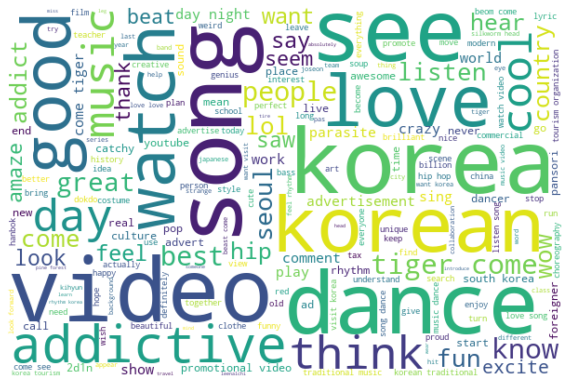

In [17]:
from wordcloud import WordCloud

all_words_lem = ' '.join([word for word in df['text_string_lem']])

wordcloud = WordCloud(width=600, 
                     height=400, 
                     random_state=2, 
                     background_color='white', 
                     max_font_size=100).generate(all_words_lem)


plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off');

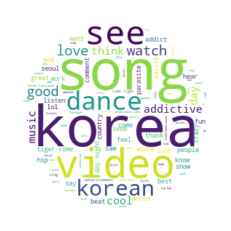

In [18]:
x, y = np.ogrid[:300, :300]
mask = (x - 150) ** 2 + (y - 150) ** 2 > 130 ** 2
mask = 255 * mask.astype(int)

wc = WordCloud(background_color="white", repeat=True, mask=mask)
wc.generate(all_words_lem)

plt.axis("off")
plt.imshow(wc, interpolation="bilinear");

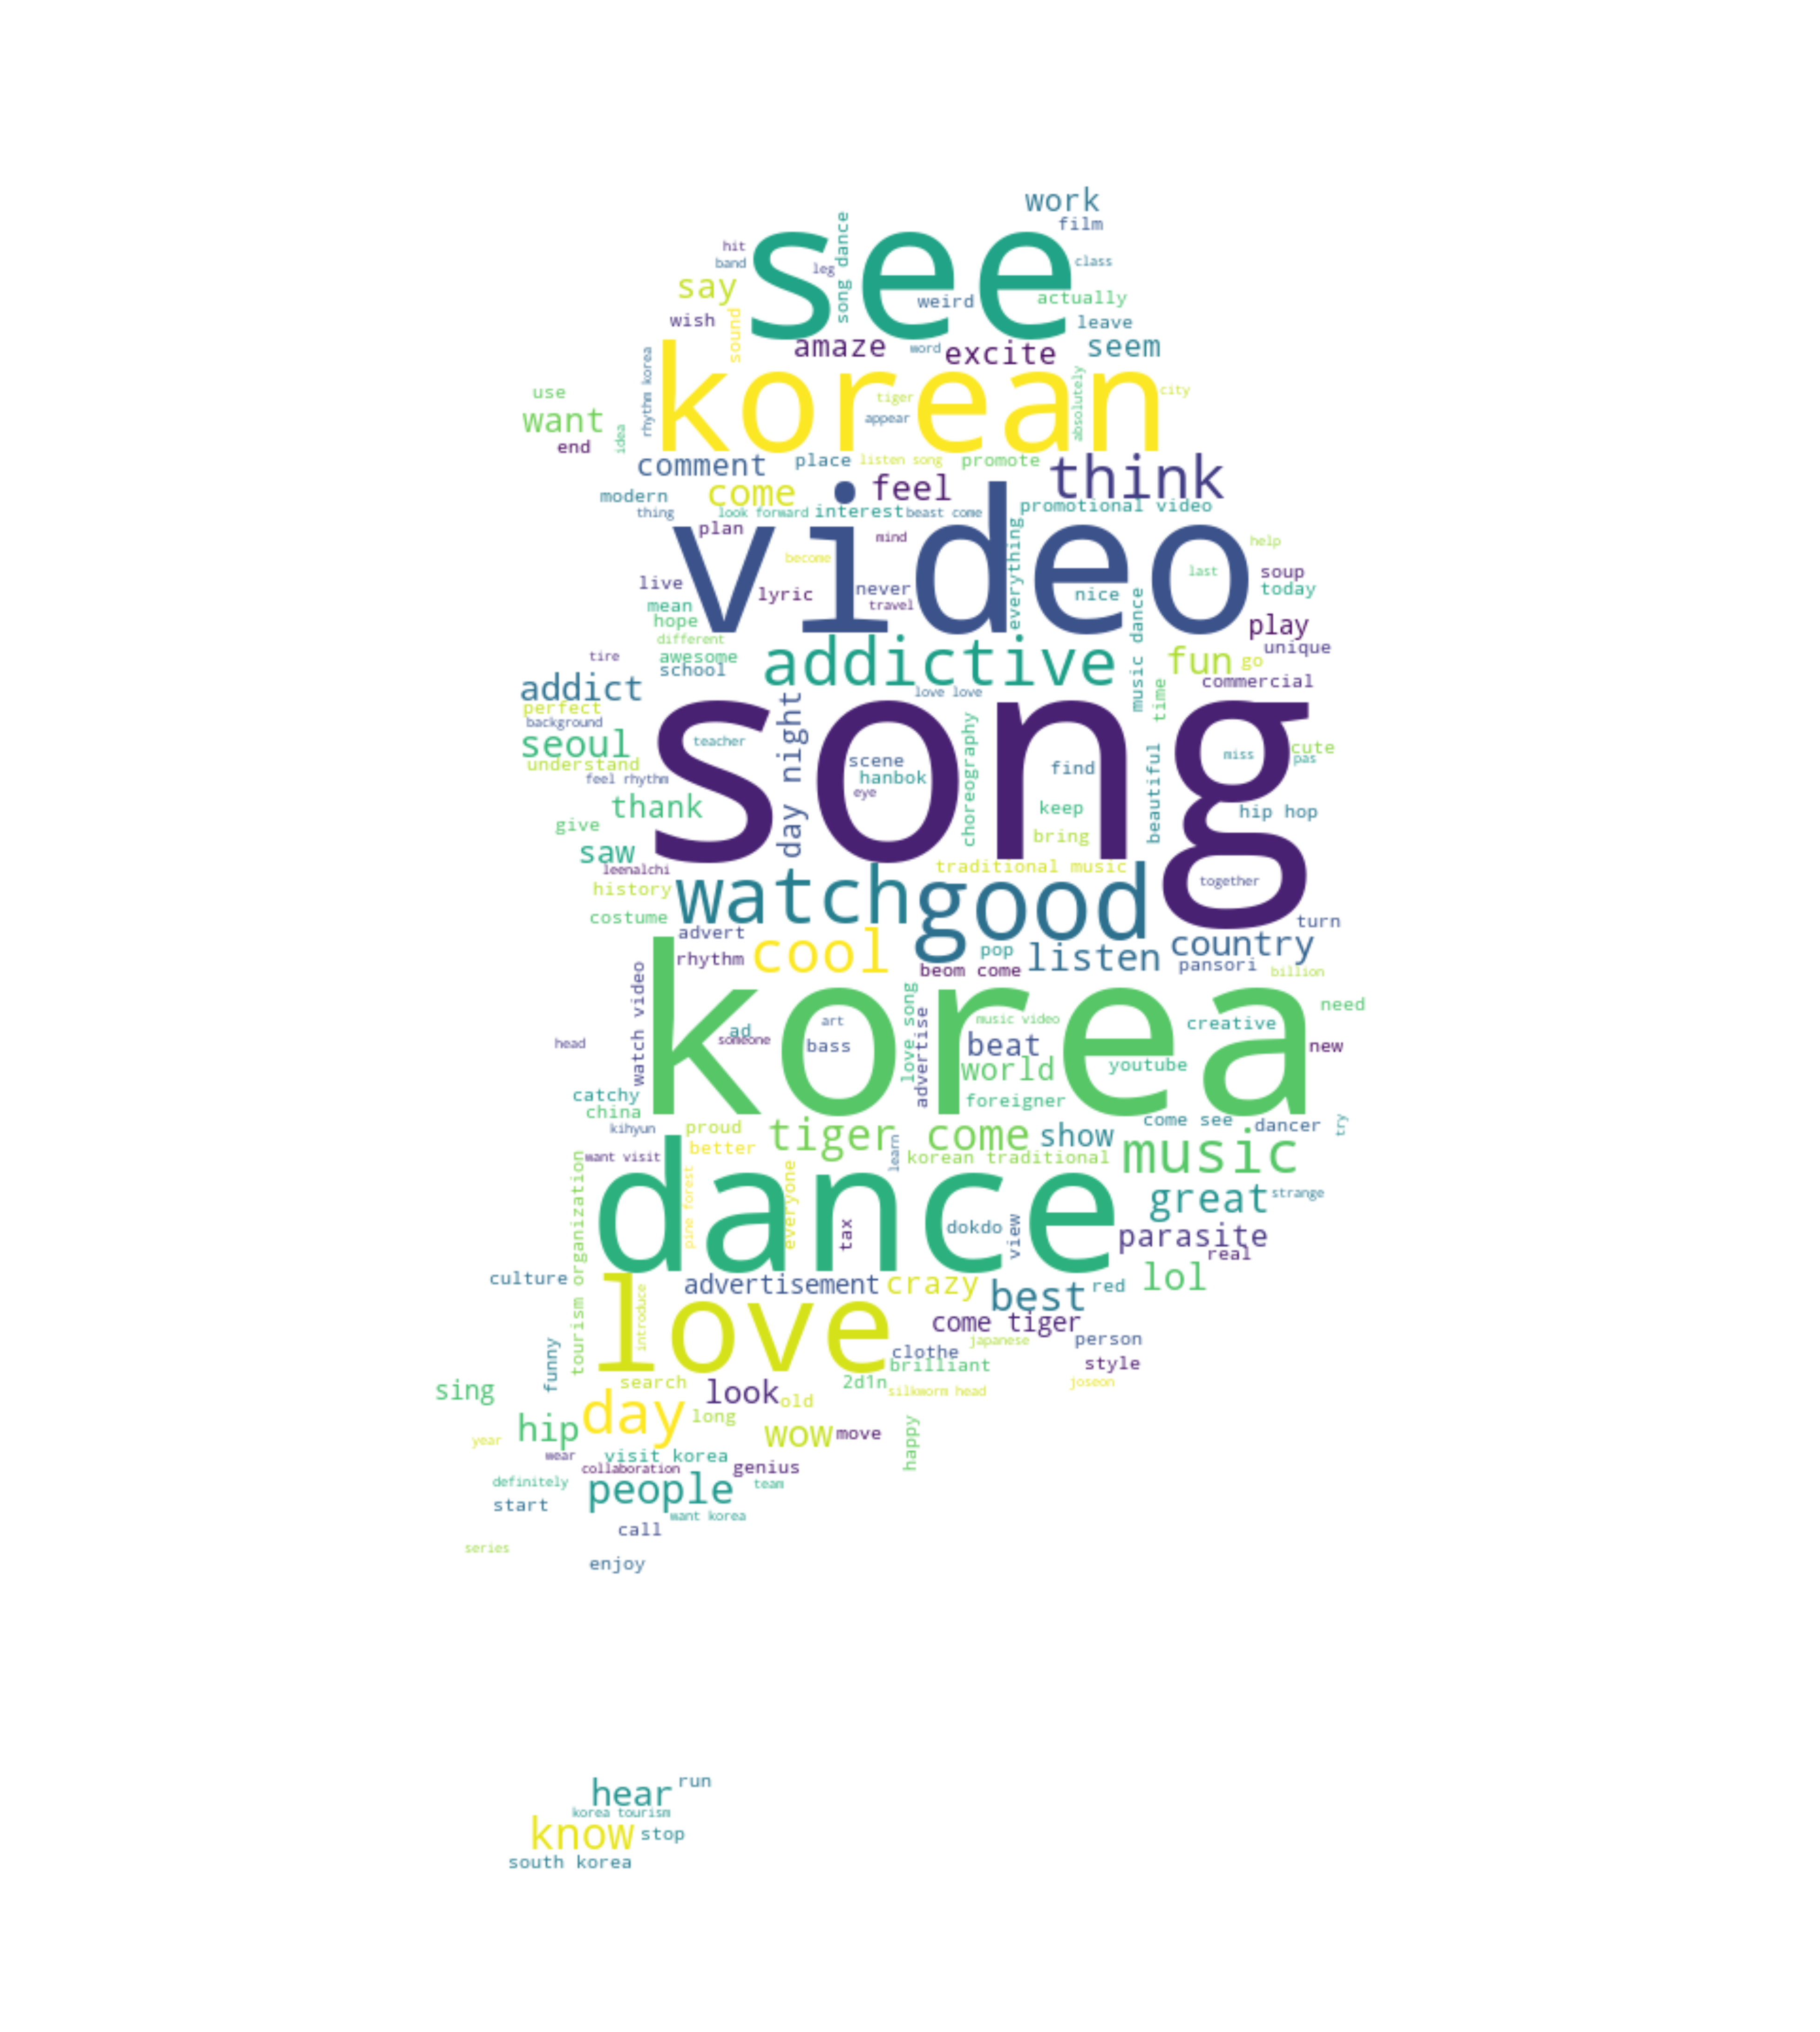

In [19]:
from wordcloud import WordCloud
mask = np.array(Image.open(r'C:\Users\jwan0\South-Korea-Map.png'))
all_words_lem = ' '.join([word for word in df['text_string_lem']])

wordcloud = WordCloud(random_state=2, 
                     background_color='white', 
                     mask = mask,
                     width = mask.shape[1],
                     height = mask.shape[0],
                     max_font_size=300).generate(all_words_lem)


plt.figure(figsize=(100, 80))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off');

In [20]:
#Word frequency list

from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist

words = nltk.word_tokenize(all_words_lem)
fd = FreqDist(words)

In [21]:
fd.most_common(200)

[('korea', 568),
 ('like', 546),
 ('come', 528),
 ('song', 509),
 ('video', 487),
 ('dance', 481),
 ('korean', 423),
 ('see', 413),
 ('love', 395),
 ('watch', 367),
 ('day', 316),
 ('good', 298),
 ('music', 255),
 ('tiger', 254),
 ('addictive', 216),
 ('hip', 177),
 ('think', 173),
 ('cool', 163),
 ('want', 158),
 ('know', 155),
 ('listen', 150),
 ('best', 147),
 ('people', 145),
 ('feel', 141),
 ('great', 136),
 ('seoul', 131),
 ('lol', 123),
 ('fun', 120),
 ('wow', 119),
 ('parasite', 116),
 ('look', 115),
 ('addict', 113),
 ('traditional', 108),
 ('hear', 108),
 ('country', 107),
 ('night', 101),
 ('time', 100),
 ('say', 99),
 ('head', 97),
 ('saw', 92),
 ('rhythm', 92),
 ('tourism', 86),
 ('visit', 82),
 ('sing', 81),
 ('beat', 80),
 ('seem', 79),
 ('amaze', 79),
 ('show', 79),
 ('thank', 79),
 ('world', 78),
 ('excite', 77),
 ('comment', 76),
 ('sound', 76),
 ('stop', 74),
 ('advertisement', 74),
 ('work', 73),
 ('youtube', 73),
 ('crazy', 72),
 ('culture', 69),
 ('promotional', 6

In [22]:
word_rank = fd.most_common(200)

WR = pd.DataFrame(word_rank)

WR.to_excel('Word_top_200_sw.xlsx')

In [23]:
top_20 = fd.most_common(20)

fdist = pd.Series(dict(top_20))

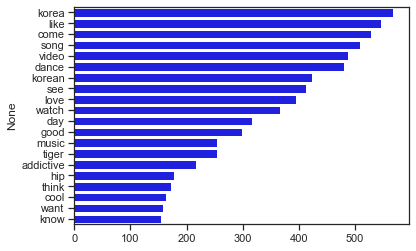

In [24]:
sns.set_theme(style="ticks")

sns.barplot(y=fdist.index, x=fdist.values, color='blue');

In [25]:
from nltk.sentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

df['polarity'] = df['text_string_lem'].apply(lambda x: analyzer.polarity_scores(x))
df.head()

,ID,user_name,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal,polarity
0,1,YM Park,태어나서 이렇게 한국적이면서 힙한 컨텐츠를 본적이 없다 진심 천재적이다 이게 공사에...,i've never seen such korean and hip content in...,"[never, seen, korean, hip, content, life, genu...",never seen korean hip content life genuinely g...,never seen korean hip content life genuinely g...,never see korean hip content life genuinely ge...,False,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound..."
1,2,유철희,"이건 일년이 지나도, 추후 몇 년이 지나도역대급이라 관련 담당자분들 더 열일 할 수...","even after a year or a few years pass, this is...","[years, pass, best, give, compliments, comment...",years pass best give compliments comments peri...,years pass best give compliments comments peri...,year pas best give compliment comment periodic...,False,"{'neg': 0.0, 'neu': 0.552, 'pos': 0.448, 'comp..."
2,3,Deep wish Kim,한국 관광공사에도 일부 꼰대들이 있을텐데 그걸 제끼고 올라온 누군가의 열정과 추진력...,there must be some kkondaes in the korea touri...,"[must, kkondaes, korea, tourism, organization,...",must kkondaes korea tourism organization comme...,must kkondaes korea tourism organization comme...,must kkondaes korea tourism organization comme...,False,"{'neg': 0.0, 'neu': 0.58, 'pos': 0.42, 'compou..."
3,4,AQ unit7,한두달에 한번은 다시 들으러 오게 되는데 이번엔 콜플 콜라보보고 생각나서 ㅋㅋ서울편...,i come here to listen to it again once or twic...,"[listen, twice, month, remember, seeing, colpl...",listen twice month remember seeing colple coll...,listen twice month remember seeing colple coll...,listen twice month remember see colple collabo...,False,"{'neg': 0.0, 'neu': 0.843, 'pos': 0.157, 'comp..."
4,5,Nicolas Goldring,"I've recently gained a passion for Korea, and ...","i've recently gained a passion for korea, and ...","[recently, gained, passion, korea, day, dreame...",recently gained passion korea day dreamed able...,recently gained passion korea day dreamed able...,recently gain passion korea day dream able tra...,False,"{'neg': 0.0, 'neu': 0.351, 'pos': 0.649, 'comp..."


In [26]:
df = pd.concat(
    [df.drop(['polarity'], axis=1), df['polarity'].apply(pd.Series)], axis=1)
df.head()

,ID,user_name,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal,neg,neu,pos,compound
0,1,YM Park,태어나서 이렇게 한국적이면서 힙한 컨텐츠를 본적이 없다 진심 천재적이다 이게 공사에...,i've never seen such korean and hip content in...,"[never, seen, korean, hip, content, life, genu...",never seen korean hip content life genuinely g...,never seen korean hip content life genuinely g...,never see korean hip content life genuinely ge...,False,0.0,1.000,0.000,0.0000
1,2,유철희,"이건 일년이 지나도, 추후 몇 년이 지나도역대급이라 관련 담당자분들 더 열일 할 수...","even after a year or a few years pass, this is...","[years, pass, best, give, compliments, comment...",years pass best give compliments comments peri...,years pass best give compliments comments peri...,year pas best give compliment comment periodic...,False,0.0,0.552,0.448,0.8074
2,3,Deep wish Kim,한국 관광공사에도 일부 꼰대들이 있을텐데 그걸 제끼고 올라온 누군가의 열정과 추진력...,there must be some kkondaes in the korea touri...,"[must, kkondaes, korea, tourism, organization,...",must kkondaes korea tourism organization comme...,must kkondaes korea tourism organization comme...,must kkondaes korea tourism organization comme...,False,0.0,0.580,0.420,0.7003
3,4,AQ unit7,한두달에 한번은 다시 들으러 오게 되는데 이번엔 콜플 콜라보보고 생각나서 ㅋㅋ서울편...,i come here to listen to it again once or twic...,"[listen, twice, month, remember, seeing, colpl...",listen twice month remember seeing colple coll...,listen twice month remember seeing colple coll...,listen twice month remember see colple collabo...,False,0.0,0.843,0.157,0.4215
4,5,Nicolas Goldring,"I've recently gained a passion for Korea, and ...","i've recently gained a passion for korea, and ...","[recently, gained, passion, korea, day, dreame...",recently gained passion korea day dreamed able...,recently gained passion korea day dreamed able...,recently gain passion korea day dream able tra...,False,0.0,0.351,0.649,0.9601


In [27]:
df['sentiment'] = df['compound'].apply(lambda x: 'positive' if x >0 else 'neutral' if x==0 else 'negative')
df.head()

,ID,user_name,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal,neg,neu,pos,compound,sentiment
0,1,YM Park,태어나서 이렇게 한국적이면서 힙한 컨텐츠를 본적이 없다 진심 천재적이다 이게 공사에...,i've never seen such korean and hip content in...,"[never, seen, korean, hip, content, life, genu...",never seen korean hip content life genuinely g...,never seen korean hip content life genuinely g...,never see korean hip content life genuinely ge...,False,0.0,1.000,0.000,0.0000,neutral
1,2,유철희,"이건 일년이 지나도, 추후 몇 년이 지나도역대급이라 관련 담당자분들 더 열일 할 수...","even after a year or a few years pass, this is...","[years, pass, best, give, compliments, comment...",years pass best give compliments comments peri...,years pass best give compliments comments peri...,year pas best give compliment comment periodic...,False,0.0,0.552,0.448,0.8074,positive
2,3,Deep wish Kim,한국 관광공사에도 일부 꼰대들이 있을텐데 그걸 제끼고 올라온 누군가의 열정과 추진력...,there must be some kkondaes in the korea touri...,"[must, kkondaes, korea, tourism, organization,...",must kkondaes korea tourism organization comme...,must kkondaes korea tourism organization comme...,must kkondaes korea tourism organization comme...,False,0.0,0.580,0.420,0.7003,positive
3,4,AQ unit7,한두달에 한번은 다시 들으러 오게 되는데 이번엔 콜플 콜라보보고 생각나서 ㅋㅋ서울편...,i come here to listen to it again once or twic...,"[listen, twice, month, remember, seeing, colpl...",listen twice month remember seeing colple coll...,listen twice month remember seeing colple coll...,listen twice month remember see colple collabo...,False,0.0,0.843,0.157,0.4215,positive
4,5,Nicolas Goldring,"I've recently gained a passion for Korea, and ...","i've recently gained a passion for korea, and ...","[recently, gained, passion, korea, day, dreame...",recently gained passion korea day dreamed able...,recently gained passion korea day dreamed able...,recently gain passion korea day dream able tra...,False,0.0,0.351,0.649,0.9601,positive


In [28]:
df.loc[df['compound'].idxmax()].values
print()
# Tweet with highest negative sentiment 
# ...seems to be a case of wrong classification because of the word "deficit"
df.loc[df['compound'].idxmin()].values

array(['3324', '  서와Etymologist',
       '《🇰🇷CHOSEN is the old Korean country name.》All of the old place names in West Asia that encompass Europe are written in Korean language pronunciation.  For example, 🇩🇪 German Potsdam is the Korean language, and the original Korean pronunciation is "Bot Dam or Bou Dam". This refers to a small reservoir or dam containing water. Ancient Korean ancestors determined the place names based on the characteristics of the terrain. All English pronunciations are Korean language pronunciations. The language of the world is rooted in the Korean language. Koreans have ruled the world for at least 5000 years and are the founders of metal civilization. The ancestors of the fathers of the people of the world are ancient Koreans, who married his mother in the region and made his children king.  In other words, the current trait is that the maternal lineage is dominant.  So, there are differences in skin color, and all of your mental civilizations were left by Kor

C:\Users\Public\Documents\ESTsoft\CreatorTemp/ipykernel_29620/680967065.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment',


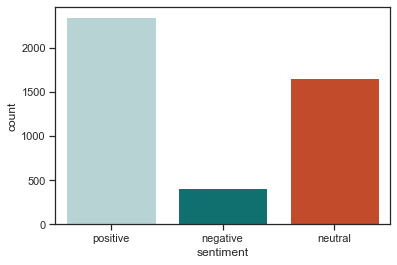

In [29]:
emo_order = ['positive', 'negative', 'neutral']

sns.countplot(x='sentiment', 
             data=df, order = emo_order,
             palette=['#b2d8d8',"#008080", '#db3d13']);

C:\Users\Public\Documents\ESTsoft\CreatorTemp/ipykernel_29620/2680373653.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='compound',


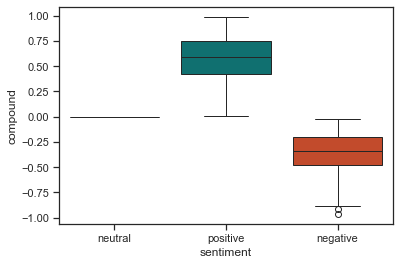

In [30]:
sns.boxplot(y='compound', 
            x='sentiment',
            palette=['#b2d8d8',"#008080", '#db3d13'], 
            data=df);

In [31]:
WR.to_excel('Word_top_200_sw.xlsx')

In [32]:
#social network
translated_text = df['text_string_lem']
translated_text.reset_index(inplace=True, drop=True) # 인덱스 초기화

In [33]:
tokenizer = RegexpTokenizer('[\w]+')

count = {} # 동시출현 빈도가 저장될 dict

for line in translated_text:
    words = line
    tokens = tokenizer.tokenize(words) # 각 리뷰를 토큰화한 뒤 리스트에 저장
    stopped_tokens = [i for i in list(set(tokens)) if not i in stopwords]
    stopped_tokens2 = [i for i in stopped_tokens if len(i)>1]
    for i,a in enumerate(stopped_tokens2):
        for b in stopped_tokens2[i+1:]:
            if a>b:
                count[b,a] = count.get((b,a),0) + 1
            else:
                count[a,b] = count.get((a,b),0) + 1
                
df1 = pd.DataFrame.from_dict(count, orient='index')

list1=[]
for i in range(len(df)):
    list1.append([df1.index[i][0], df1.index[i][1], df1[0][i]])

df2 = pd.DataFrame(list1, columns=['term1','term2','freq'])
df3 = df2.sort_values(by=['freq'], ascending=False) # freq 기준으로 내림차순 정렬
df3_nw = df3.reset_index(drop=True)

C:\Users\Public\Documents\ESTsoft\CreatorTemp/ipykernel_29620/3785069860.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  list1.append([df1.index[i][0], df1.index[i][1], df1[0][i]])


In [34]:
YT_kr_nw = nx.Graph()

# 동시출현 빈도가 n이상인 단어들에 대해서만 중심성 계수 계산
n = 27
for i in range((len(np.where(df3_nw['freq']>n)[0]))):
    YT_kr_nw.add_edge(df3_nw['term1'][i], df3_nw['term2'][i],
                  weight=int(df3_nw['freq'][i]))

dgr = nx.degree_centrality(YT_kr_nw) # 연결 중심성
btw = nx.betweenness_centrality(YT_kr_nw) # 매개 중심성
cls = nx.closeness_centrality(YT_kr_nw) # 근접 중심성
egv = nx.eigenvector_centrality(YT_kr_nw) # 고유벡터 중심성

sorted_dgr = sorted(dgr.items(), key=operator.itemgetter(1), reverse=True)
sorted_btw = sorted(btw.items(), key=operator.itemgetter(1), reverse=True)
sorted_cls = sorted(cls.items(), key=operator.itemgetter(1), reverse=True)
sorted_egv = sorted(egv.items(), key=operator.itemgetter(1), reverse=True)

print("** degree **")
for x in range(28):
    print(sorted_dgr[x])

print("** betweenness **")
for x in range(28):
    print(sorted_btw[x])
    
print("** closeness **")
for x in range(28):
    print(sorted_cls[x])

print("** eigenvector **")
for x in range(28):
    print(sorted_egv[x])

** degree **
('korea', 0.7037037037037037)
('dance', 0.48148148148148145)
('like', 0.4444444444444444)
('song', 0.4074074074074074)
('video', 0.3333333333333333)
('watch', 0.2962962962962963)
('korean', 0.2962962962962963)
('see', 0.2962962962962963)
('music', 0.25925925925925924)
('good', 0.2222222222222222)
('love', 0.18518518518518517)
('want', 0.14814814814814814)
('visit', 0.1111111111111111)
('day', 0.1111111111111111)
('traditional', 0.07407407407407407)
('feel', 0.07407407407407407)
('addictive', 0.07407407407407407)
('tourism', 0.07407407407407407)
('tiger', 0.07407407407407407)
('people', 0.07407407407407407)
('south', 0.037037037037037035)
('organization', 0.037037037037037035)
('country', 0.037037037037037035)
('sing', 0.037037037037037035)
('hip', 0.037037037037037035)
('best', 0.037037037037037035)
('sound', 0.037037037037037035)
('stop', 0.037037037037037035)
** betweenness **
('korea', 0.49198661420883644)
('dance', 0.14994799439243886)
('like', 0.13837787726676617)
('k

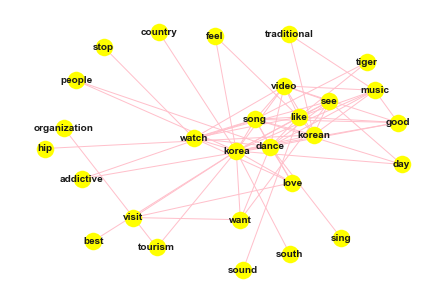

<Figure size 2e+06x2e+06 with 0 Axes>

In [35]:
nx.draw(YT_kr_nw, pos = nx.spring_layout(YT_kr_nw, k=5),
    node_color='yellow', linewidths=0.125, font_size=10,
    font_weight='bold', edge_color= 'pink', with_labels=True)

plt.figure(num=None, figsize=(2000, 2000), dpi=1000)


plt.show()

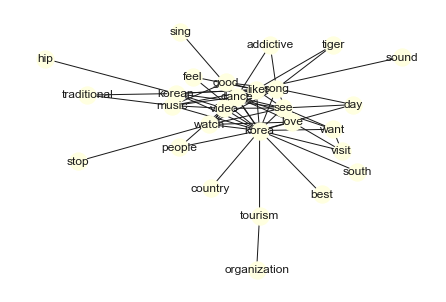

In [36]:
nx.draw(YT_kr_nw, node_color='lightyellow', with_labels = True)

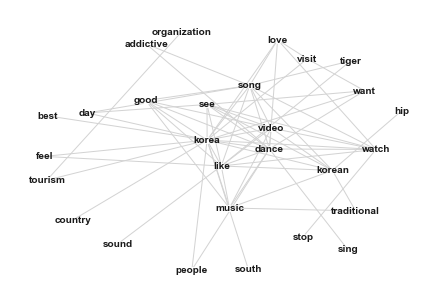

<Figure size 2e+06x2e+06 with 0 Axes>

In [37]:
nx.draw(YT_kr_nw, pos = nx.spring_layout(YT_kr_nw, k=5),
    node_color='white', linewidths=0, font_size=10, node_size = 50,
    font_weight='bold', edge_color= 'lightgrey', with_labels=True)

plt.figure(num=None, figsize=(2000, 2000), dpi=1000)


plt.show()

In [38]:
#LDA Topic modeling
stop_words = stopwords

vect =TfidfVectorizer(stop_words=stop_words,max_features=1000)
vect_text=vect.fit_transform(df['text_string_lem'])

In [39]:
from sklearn.decomposition import LatentDirichletAllocation
lda_model=LatentDirichletAllocation(n_components=10,
learning_method='online',random_state=42,max_iter=1) 
lda_top=lda_model.fit_transform(vect_text)

In [40]:
print("Document : ")
for i,topic in enumerate(lda_top[0]):
  print("Topic ",i+1,": ",topic*100,"%")

Document : 
Topic  1 :  2.8079862813382794 %
Topic  2 :  2.80805428686924 %
Topic  3 :  2.808157317472238 %
Topic  4 :  2.808211221675057 %
Topic  5 :  2.807978601900057 %
Topic  6 :  2.80817442292735 %
Topic  7 :  74.72596593233106 %
Topic  8 :  2.8086114265759847 %
Topic  9 :  2.8086928851110486 %
Topic  10 :  2.8081676237996835 %


In [41]:
vocab = vect.get_feature_names()
for i, comp in enumerate(lda_model.components_):
     vocab_comp = zip(vocab, comp)
     sorted_words = sorted(vocab_comp, key= lambda x:x[1], reverse=True)[:10]
     print("Topic "+str(i+1)+": ")
     for t in sorted_words:
            print(t[0],end=" ")
            print('\n')

Topic 1: 
day 

watch 

addict 

night 

bring 

2d1n 

look 

stop 

listen 

best 

Topic 2: 
soup 

billion 

comment 

head 

dance 

film 

sing 

leave 

tax 

new 

Topic 3: 
crazy 

amaze 

great 

person 

korea 

school 

plan 

want 

country 

number 

Topic 4: 
cool 

kihyun 

thank 

organization 

tourism 

together 

tiger 

korea 

change 

song 

Topic 5: 
parasite 

awesome 

beom 

parody 

foreigner 

movie 

tunnel 

scene 

cute 

poster 

Topic 6: 
good 

video 

korean 

like 

people 

real 

watch 

dance 

youtube 

promotional 

Topic 7: 
hip 

korea 

korean 

hop 

music 

know 

like 

saw 

genius 

show 

Topic 8: 
fun 

view 

seoul 

like 

ad 

today 

place 

million 

see 

turn 

Topic 9: 
addictive 

see 

lol 

think 

hear 

rhythm 

watch 

excite 

like 

day 

Topic 10: 
wow 

tiger 

love 

song 

beat 

funny 

dance 

understand 

mind 

end 



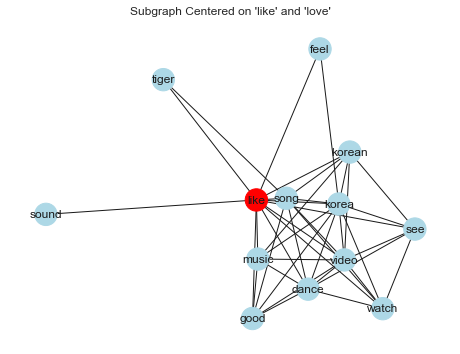

In [42]:
# Define your center keywords
center_keywords = 'like'

# Ensure these nodes exist in the full network
center_nodes = [node for node in YT_kr_nw.nodes() if node in center_keywords]

# Collect all neighbors (1-hop) of the center keywords
neighbors = set()
for node in center_nodes:
    neighbors.update(nx.all_neighbors(YT_kr_nw, node))
# Also include the center nodes themselves
neighbors.update(center_nodes)

# Create the subgraph
subgraph = YT_kr_nw.subgraph(neighbors)

# (Optional) Compute centrality measures for additional insight
degree_cent = nx.degree_centrality(subgraph)
betweenness_cent = nx.betweenness_centrality(subgraph)
closeness_cent = nx.closeness_centrality(subgraph)
eigenvector_cent = nx.eigenvector_centrality(subgraph)


# Visualize the subgraph
pos = nx.spring_layout(subgraph, seed=42)
node_colors = ['red' if node in center_keywords else 'lightblue' for node in subgraph.nodes()]

plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(subgraph, pos, node_color=node_colors, node_size=500)
nx.draw_networkx_edges(subgraph, pos)
nx.draw_networkx_labels(subgraph, pos)
plt.title("Subgraph Centered on 'like' and 'love'")
plt.axis('off')
plt.show()

In [54]:
# Create a DataFrame to combine these centrality measures
centralities_table = pd.DataFrame({
    'Node': list(subgraph.nodes()),
    'Degree': [degree_cent[node] for node in subgraph.nodes()],
    'Betweenness': [betweenness_cent[node] for node in subgraph.nodes()],
    'Closeness': [closeness_cent[node] for node in subgraph.nodes()],
    'Eigenvector': [eigenvector_cent[node] for node in subgraph.nodes()]
})

# Sort the table by Degree centrality (or any other measure) for easier interpretation
centralities_table = centralities_table.sort_values(by='Degree', ascending=False)

# Display the table
print(centralities_table)

centralities_table.head(13)

         Node    Degree  Betweenness  Closeness  Eigenvector
10       song  1.000000     0.305152   1.000000     0.415372
4       korea  0.818182     0.105152   0.846154     0.385957
2       dance  0.727273     0.073333   0.785714     0.356815
3        like  0.727273     0.071818   0.785714     0.357529
7       video  0.636364     0.017273   0.733333     0.342815
8       watch  0.545455     0.009091   0.687500     0.306734
11       good  0.454545     0.000000   0.647059     0.274724
6        love  0.363636     0.000000   0.611111     0.216541
9      korean  0.363636     0.000000   0.611111     0.221979
0       tiger  0.181818     0.000000   0.550000     0.114251
1         day  0.181818     0.000000   0.550000     0.118454
5   addictive  0.181818     0.000000   0.550000     0.114146


,Node,Degree,Betweenness,Closeness,Eigenvector
10,song,1.000000,0.305152,1.000000,0.415372
4,korea,0.818182,0.105152,0.846154,0.385957
2,dance,0.727273,0.073333,0.785714,0.356815
3,like,0.727273,0.071818,0.785714,0.357529
7,video,0.636364,0.017273,0.733333,0.342815
8,watch,0.545455,0.009091,0.687500,0.306734
11,good,0.454545,0.000000,0.647059,0.274724
6,love,0.363636,0.000000,0.611111,0.216541
9,korean,0.363636,0.000000,0.611111,0.221979
0,tiger,0.181818,0.000000,0.550000,0.114251


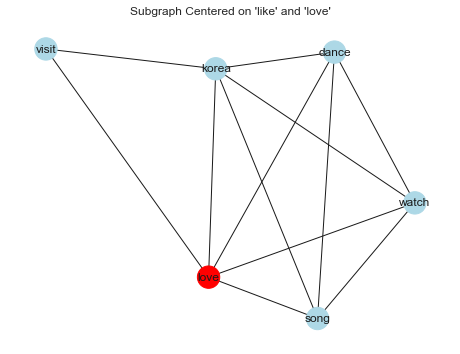

In [44]:
# Define your center keywords
center_keywords = 'love'

# Ensure these nodes exist in the full network
center_nodes = [node for node in YT_kr_nw.nodes() if node in center_keywords]

# Collect all neighbors (1-hop) of the center keywords
neighbors = set()
for node in center_nodes:
    neighbors.update(nx.all_neighbors(YT_kr_nw, node))
# Also include the center nodes themselves
neighbors.update(center_nodes)

# Create the subgraph
subgraph = YT_kr_nw.subgraph(neighbors)

# (Optional) Compute centrality measures for additional insight
degree_cent = nx.degree_centrality(subgraph)
betweenness_cent = nx.betweenness_centrality(subgraph)
closeness_cent = nx.closeness_centrality(subgraph)
eigenvector_cent = nx.eigenvector_centrality(subgraph)

# Visualize the subgraph
pos = nx.spring_layout(subgraph, seed=42)
node_colors = ['red' if node in center_keywords else 'lightblue' for node in subgraph.nodes()]

plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(subgraph, pos, node_color=node_colors, node_size=500)
nx.draw_networkx_edges(subgraph, pos)
nx.draw_networkx_labels(subgraph, pos)
plt.title("Subgraph Centered on 'like' and 'love'")
plt.axis('off')
plt.show()

In [45]:
# Create a DataFrame to combine these centrality measures
centralities_table = pd.DataFrame({
    'Node': list(subgraph.nodes()),
    'Degree': [degree_cent[node] for node in subgraph.nodes()],
    'Betweenness': [betweenness_cent[node] for node in subgraph.nodes()],
    'Closeness': [closeness_cent[node] for node in subgraph.nodes()],
    'Eigenvector': [eigenvector_cent[node] for node in subgraph.nodes()]
})

# Sort the table by Degree centrality (or any other measure) for easier interpretation
centralities_table = centralities_table.sort_values(by='Degree', ascending=False)

# Display the table
print(centralities_table)

    Node  Degree  Betweenness  Closeness  Eigenvector
2  korea     1.0         0.15   1.000000     0.461137
3   love     1.0         0.15   1.000000     0.461137
0  dance     0.8         0.00   0.833333     0.418935
1  watch     0.8         0.00   0.833333     0.418935
4   song     0.8         0.00   0.833333     0.418935
5  visit     0.4         0.00   0.625000     0.219513


In [47]:
# Create a DataFrame to combine these centrality measures
centralities_table = pd.DataFrame({
    'Node': list(subgraph.nodes()),
    'Degree': [degree_centrality[node] for node in subgraph.nodes()],
    'Betweenness': [betweenness_centrality[node] for node in subgraph.nodes()],
    'Closeness': [closeness_centrality[node] for node in subgraph.nodes()],
    'Eigenvector': [eigenvector_centrality[node] for node in subgraph.nodes()]
})

# Sort the table by Degree centrality (or any other measure) for easier interpretation
centralities_table = centralities_table.sort_values(by='Degree', ascending=False)

# Display the table
print(centralities_table)

NameError: name 'degree_centrality' is not defined

Topic 0: ['day', 'watch', 'addict', 'night', 'bring', '2d1n', 'look', 'stop', 'listen', 'best']
Topic 1: ['soup', 'billion', 'comment', 'head', 'dance', 'film', 'sing', 'leave', 'tax', 'new']
Topic 2: ['crazy', 'amaze', 'great', 'person', 'korea', 'school', 'plan', 'want', 'country', 'number']
Topic 3: ['cool', 'kihyun', 'thank', 'organization', 'tourism', 'together', 'tiger', 'korea', 'change', 'song']
Topic 4: ['parasite', 'awesome', 'beom', 'parody', 'foreigner', 'movie', 'tunnel', 'scene', 'cute', 'poster']
Topic 5: ['good', 'video', 'korean', 'like', 'people', 'real', 'watch', 'dance', 'youtube', 'promotional']
Topic 6: ['hip', 'korea', 'korean', 'hop', 'music', 'know', 'like', 'saw', 'genius', 'show']
Topic 7: ['fun', 'view', 'seoul', 'like', 'ad', 'today', 'place', 'million', 'see', 'turn']
Topic 8: ['addictive', 'see', 'lol', 'think', 'hear', 'rhythm', 'watch', 'excite', 'like', 'day']
Topic 9: ['wow', 'tiger', 'love', 'song', 'beat', 'funny', 'dance', 'understand', 'mind', 'en

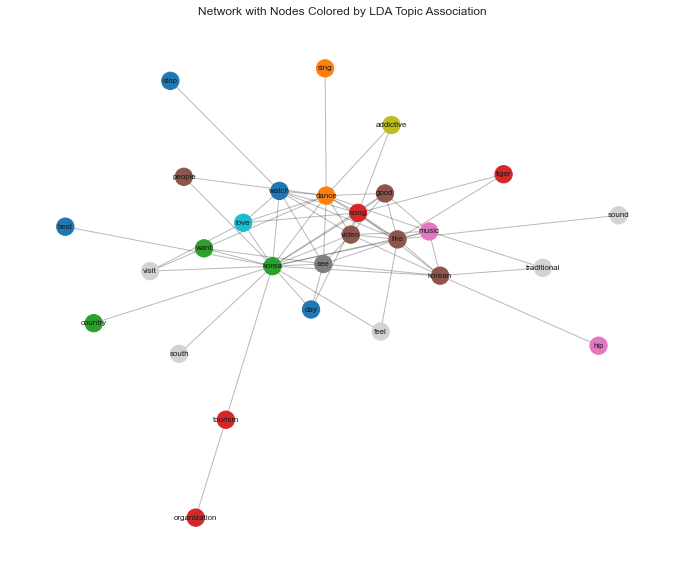

In [48]:
# Number of top words to extract per topic
num_top_words = 10
vocab = vect.get_feature_names()  # from your TfidfVectorizer
topic_top_words = {}

# Extract top words for each topic
for topic_idx, topic in enumerate(lda_model.components_):
    top_indices = topic.argsort()[-num_top_words:][::-1]
    topic_top_words[topic_idx] = [vocab[i] for i in top_indices]
    print(f"Topic {topic_idx}: {topic_top_words[topic_idx]}")

# Create a mapping: word -> list of topics where it appears in the top words
node_topic_mapping = {}
for topic_idx, words in topic_top_words.items():
    for word in words:
        if word in YT_kr_nw.nodes():
            node_topic_mapping.setdefault(word, []).append(topic_idx)

# For visualization, assign a color based on the first associated topic.
# (You can expand this if a node is linked to multiple topics.)
color_map = []
for node in YT_kr_nw.nodes():
    if node in node_topic_mapping:
        # Use the topic index to select a color from a colormap (e.g., tab10)
        topic_idx = node_topic_mapping[node][0]
        color = plt.cm.tab10(topic_idx)
    else:
        color = 'lightgrey'
    color_map.append(color)

# Visualize the full network with nodes colored by their LDA topic association
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(YT_kr_nw, seed=42)
nx.draw_networkx_nodes(YT_kr_nw, pos, node_color=color_map, node_size=300)
nx.draw_networkx_edges(YT_kr_nw, pos, alpha=0.3)
nx.draw_networkx_labels(YT_kr_nw, pos, font_size=8)
plt.title("Network with Nodes Colored by LDA Topic Association")
plt.axis('off')
plt.show()

Topic 1: ['day', 'watch', 'addict', 'night', 'bring', '2d1n', 'look', 'stop', 'listen', 'best']
Topic 2: ['soup', 'billion', 'comment', 'head', 'dance', 'film', 'sing', 'leave', 'tax', 'new']
Topic 3: ['crazy', 'amaze', 'great', 'person', 'korea', 'school', 'plan', 'want', 'country', 'number']
Topic 4: ['cool', 'kihyun', 'thank', 'organization', 'tourism', 'together', 'tiger', 'korea', 'change', 'song']
Topic 5: ['parasite', 'awesome', 'beom', 'parody', 'foreigner', 'movie', 'tunnel', 'scene', 'cute', 'poster']
Topic 6: ['good', 'video', 'korean', 'like', 'people', 'real', 'watch', 'dance', 'youtube', 'promotional']
Topic 7: ['hip', 'korea', 'korean', 'hop', 'music', 'know', 'like', 'saw', 'genius', 'show']
Topic 8: ['fun', 'view', 'seoul', 'like', 'ad', 'today', 'place', 'million', 'see', 'turn']
Topic 9: ['addictive', 'see', 'lol', 'think', 'hear', 'rhythm', 'watch', 'excite', 'like', 'day']
Topic 10: ['wow', 'tiger', 'love', 'song', 'beat', 'funny', 'dance', 'understand', 'mind', 'e

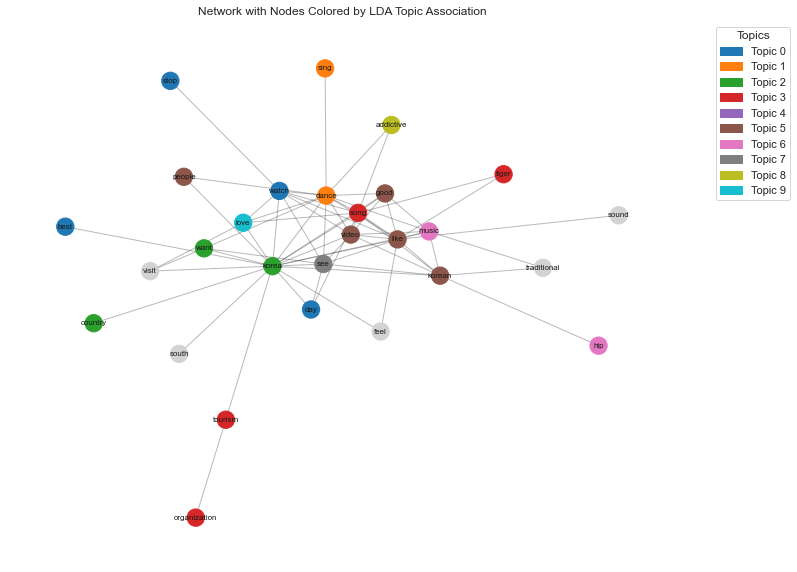

In [49]:
import matplotlib.patches as mpatches

# Number of top words to extract per topic
num_top_words = 10
vocab = vect.get_feature_names()  # from your TfidfVectorizer
topic_top_words = {}

# Extract top words for each topic
for topic_idx, topic in enumerate(lda_model.components_):
    top_indices = topic.argsort()[-num_top_words:][::-1]
    topic_top_words[topic_idx] = [vocab[i] for i in top_indices]
    print(f"Topic {topic_idx+1}: {topic_top_words[topic_idx]}")

# Create a mapping: word -> list of topics where it appears in the top words
node_topic_mapping = {}
for topic_idx, words in topic_top_words.items():
    for word in words:
        if word in YT_kr_nw.nodes():
            node_topic_mapping.setdefault(word, []).append(topic_idx)

# For visualization, assign a color based on the first associated topic.
# (You can expand this if a node is linked to multiple topics.)
color_map = []
for node in YT_kr_nw.nodes():
    if node in node_topic_mapping:
        # Use the topic index to select a color from a colormap (e.g., tab10)
        topic_idx = node_topic_mapping[node][0]
        color = plt.cm.tab10(topic_idx)
    else:
        color = 'lightgrey'
    color_map.append(color)

# Visualize the full network with nodes colored by their LDA topic association
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(YT_kr_nw, seed=42)
nx.draw_networkx_nodes(YT_kr_nw, pos, node_color=color_map, node_size=300)
nx.draw_networkx_edges(YT_kr_nw, pos, alpha=0.3)
nx.draw_networkx_labels(YT_kr_nw, pos, font_size=8)
plt.title("Network with Nodes Colored by LDA Topic Association")
plt.axis('off')

# Create legend handles for each topic using the tab10 colormap
num_topics = lda_model.components_.shape[0]
legend_handles = [
    mpatches.Patch(color=plt.cm.tab10(topic_idx), label=f"Topic {topic_idx}")
    for topic_idx in range(num_topics)
]

# Add the legend to the plot
plt.legend(handles=legend_handles, title="Topics", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


In [50]:
# Construct a DataFrame with topics and their top words
df_topics = pd.DataFrame({
    'Topic': [f"Topic {i+1}" for i in range(len(topic_top_words))],
    'Top Words': [', '.join(topic_top_words[i]) for i in range(len(topic_top_words))]
})

df_topics.head(10)

,Topic,Top Words
0,Topic 1,"day, watch, addict, night, bring, 2d1n, look, ..."
1,Topic 2,"soup, billion, comment, head, dance, film, sin..."
2,Topic 3,"crazy, amaze, great, person, korea, school, pl..."
3,Topic 4,"cool, kihyun, thank, organization, tourism, to..."
4,Topic 5,"parasite, awesome, beom, parody, foreigner, mo..."
5,Topic 6,"good, video, korean, like, people, real, watch..."
6,Topic 7,"hip, korea, korean, hop, music, know, like, sa..."
7,Topic 8,"fun, view, seoul, like, ad, today, place, mill..."
8,Topic 9,"addictive, see, lol, think, hear, rhythm, watc..."
9,Topic 10,"wow, tiger, love, song, beat, funny, dance, un..."


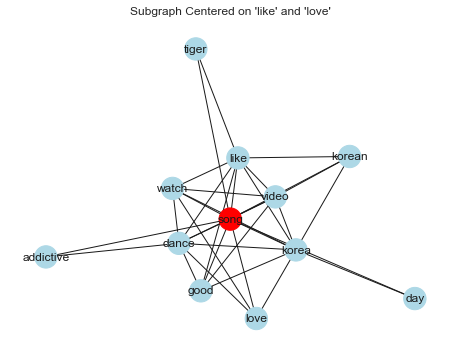

In [53]:
# Define your center keywords
center_keywords = 'song'

# Ensure these nodes exist in the full network
center_nodes = [node for node in YT_kr_nw.nodes() if node in center_keywords]

# Collect all neighbors (1-hop) of the center keywords
neighbors = set()
for node in center_nodes:
    neighbors.update(nx.all_neighbors(YT_kr_nw, node))
# Also include the center nodes themselves
neighbors.update(center_nodes)

# Create the subgraph
subgraph = YT_kr_nw.subgraph(neighbors)

# (Optional) Compute centrality measures for additional insight
degree_cent = nx.degree_centrality(subgraph)
betweenness_cent = nx.betweenness_centrality(subgraph)
closeness_cent = nx.closeness_centrality(subgraph)
eigenvector_cent = nx.eigenvector_centrality(subgraph)


# Visualize the subgraph
pos = nx.spring_layout(subgraph, seed=42)
node_colors = ['red' if node in center_keywords else 'lightblue' for node in subgraph.nodes()]

plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(subgraph, pos, node_color=node_colors, node_size=500)
nx.draw_networkx_edges(subgraph, pos)
nx.draw_networkx_labels(subgraph, pos)
plt.title("Subgraph Centered on 'like' and 'love'")
plt.axis('off')
plt.show()